# Урок 4.2. Темп обучения и число деревьев

**Интерактивная версия:** `lessons/lesson_4_2/web/index.html`

1. Кривые валидации для разных ν.
2. Закон ν·M* ≈ const.
3. Устойчивость вывода: 5 разных разбиений на обучение/валидацию.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Кривые валидации

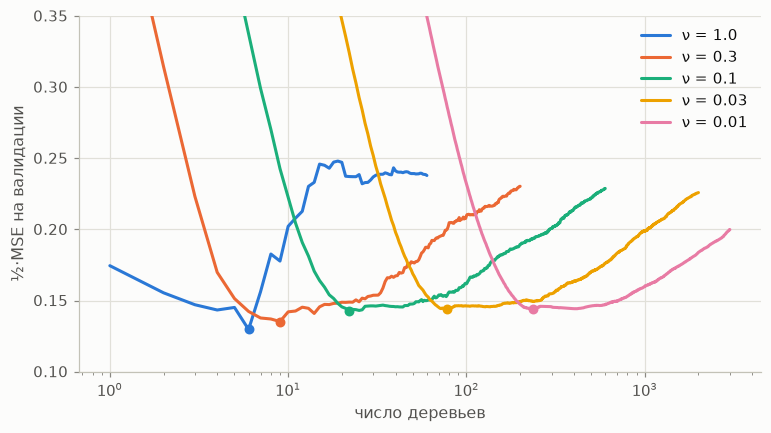

,ν,лучшее M*,ν·M*,лучшая ½MSE
0,1.00,6,6.00,0.1297
1,0.30,9,2.70,0.1352
2,0.10,22,2.20,0.1428
3,0.03,78,2.34,0.1439
4,0.01,236,2.36,0.1440


In [2]:
X, y = datasets.regression_1d(kind="wave", n=200, noise=0.5, seed=7)
X_tr, X_val, y_tr, y_val = datasets.train_test_split(X, y, test_size=0.3, seed=0)
nus = [1.0, 0.3, 0.1, 0.03, 0.01]
fig, ax = plt.subplots(figsize=(8, 4.2))
rows = []
for nu in nus:
    m = GBRegressor(n_estimators=min(3000, round(60 / nu)), learning_rate=nu, max_depth=3).fit(X_tr, y_tr, eval_set=(X_val, y_val))
    ev = np.array(m.history_["eval"])
    ax.plot(np.arange(1, len(ev)), ev[1:], label=f"ν = {nu}")
    ax.scatter([m.best_iteration_], [ev[m.best_iteration_]], s=30, zorder=3)
    rows.append({"ν": nu, "лучшее M*": m.best_iteration_, "ν·M*": nu * m.best_iteration_, "лучшая ½MSE": ev.min()})
ax.set_xscale("log")
ax.set(xlabel="число деревьев", ylabel="½·MSE на валидации", ylim=(0.1, 0.35))
ax.legend()
plt.show()
pd.DataFrame(rows).round(4)

Закон $\nu \cdot M^* \approx \text{const}$ виден хорошо. А вот лучшая ошибка на этом *одном* разбиении
оказалась у ν = 1 — вопреки «теории». Валидация из 60 точек шумная: разница в сотые доли — случайность.
Проверим на нескольких разбиениях и на данных побольше.

## 2. Устойчивость: повторим на 5 разбиениях

In [3]:
X3, y3 = datasets.regression_1d(kind="wave", n=300, noise=0.5, seed=7)
res = {nu: [] for nu in (1.0, 0.1, 0.03)}
for seed in range(5):
    Xa, Xb, ya, yb = datasets.train_test_split(X3, y3, test_size=0.3, seed=seed)
    for nu in res:
        m = GBRegressor(n_estimators=min(3000, round(60 / nu)), learning_rate=nu, max_depth=3).fit(Xa, ya, eval_set=(Xb, yb))
        res[nu].append(min(m.history_["eval"]))
for nu, v in res.items():
    print(f"ν = {nu:5}: лучшая ½MSE на валидации {np.mean(v):.4f} ± {np.std(v):.4f}")

ν =   1.0: лучшая ½MSE на валидации 0.1723 ± 0.0178
ν =   0.1: лучшая ½MSE на валидации 0.1566 ± 0.0228
ν =  0.03: лучшая ½MSE на валидации 0.1570 ± 0.0237


В среднем по разбиениям маленький темп выигрывает у ν = 1, а между 0.1 и 0.03 разница уже мала —
«до некоторого предела». Разброс между разбиениями (±) сопоставим с самим эффектом: выводы о
гиперпараметрах делайте по нескольким разбиениям или кросс-валидации (урок 11.2). Цена маленького
темпа — время обучения: в 30 раз больше деревьев.

## Упражнения

1. Для ν = 0.1 и глубин 1…6 найдите лучшие M* и ошибки. Как глубина связана с M*?
2. Постройте график времени обучения против ν. Какой ν вы выберете, если на обучение есть 10 секунд?

Решения: `python lessons/lesson_4_2/exercises/solutions.py`.